## Tugas - Klasifikasi dengan Decision Tree

| Nama | NRP |
|------|-----|
| Evina Fitriyani | 5054251013 |

### Deskripsi Tugas
Pada tugas ini, kalian akan membangun model Decision Tree Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja Decision Tree secara praktik, khususnya:
1. Perbedaan hasil antara kriteria split Gini Impurity dan Entropy
2. Pengaruh regularisasi (max_depth) terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Decision Tree dengan kriteria Gini dan Entropy.
   - Lakukan eksperimen regularisasi dengan variasi nilai max_depth.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

### 1. Persiapan Dataset dan Eksplorasi Awal

In [2]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [3]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv('bankruptcy.csv')

print('jumlah baris dan kolom:', df.shape)
df.info()
df.describe()

jumlah baris dan kolom: (6819, 96)
<class 'pandas.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,...,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,...,0.807760,1.862942e+07,0.623915,0.607946,0.840402,0.280365,0.027541,0.565358,1.0,0.047578
std,0.176710,0.060686,0.065620,0.061595,0.016934,0.016916,0.013010,0.012869,0.013601,0.011163,...,0.040332,3.764501e+08,0.012290,0.016934,0.014523,0.014463,0.015668,0.013214,0.0,0.050014
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,0.000000,0.476527,0.535543,0.527277,0.600445,0.600434,0.998969,0.797386,0.809312,0.303466,...,0.796750,9.036205e-04,0.623636,0.600443,0.840115,0.276944,0.026791,0.565158,1.0,0.024477
50%,0.000000,0.502706,0.559802,0.552278,0.605997,0.605976,0.999022,0.797464,0.809375,0.303525,...,0.810619,2.085213e-03,0.623879,0.605998,0.841179,0.278778,0.026808,0.565252,1.0,0.033798
75%,0.000000,0.535563,0.589157,0.584105,0.613914,0.613842,0.999095,0.797579,0.809469,0.303585,...,0.826455,5.269777e-03,0.624168,0.613913,0.842357,0.281449,0.026913,0.565725,1.0,0.052838
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000


In [4]:
df.isnull().sum()

Bankrupt?                                                   0
 ROA(C) before interest and depreciation before interest    0
 ROA(A) before interest and % after tax                     0
 ROA(B) before interest and depreciation after tax          0
 Operating Gross Margin                                     0
                                                           ..
 Liability to Equity                                        0
 Degree of Financial Leverage (DFL)                         0
 Interest Coverage Ratio (Interest expense to EBIT)         0
 Net Income Flag                                            0
 Equity to Liability                                        0
Length: 96, dtype: int64

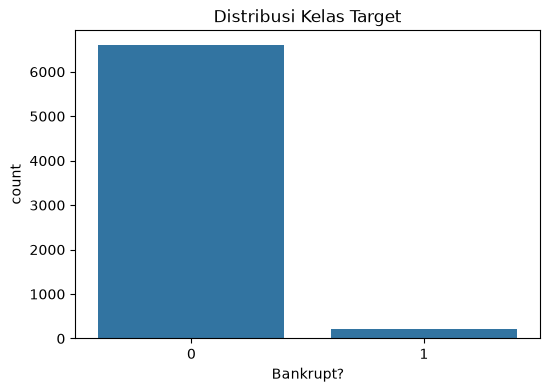

Bankrupt?
0    0.967737
1    0.032263
Name: proportion, dtype: float64


In [5]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
target_col = 'Bankrupt?'

plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df)
plt.title('Distribusi Kelas Target')
plt.show()

print(df[target_col].value_counts(normalize=True))

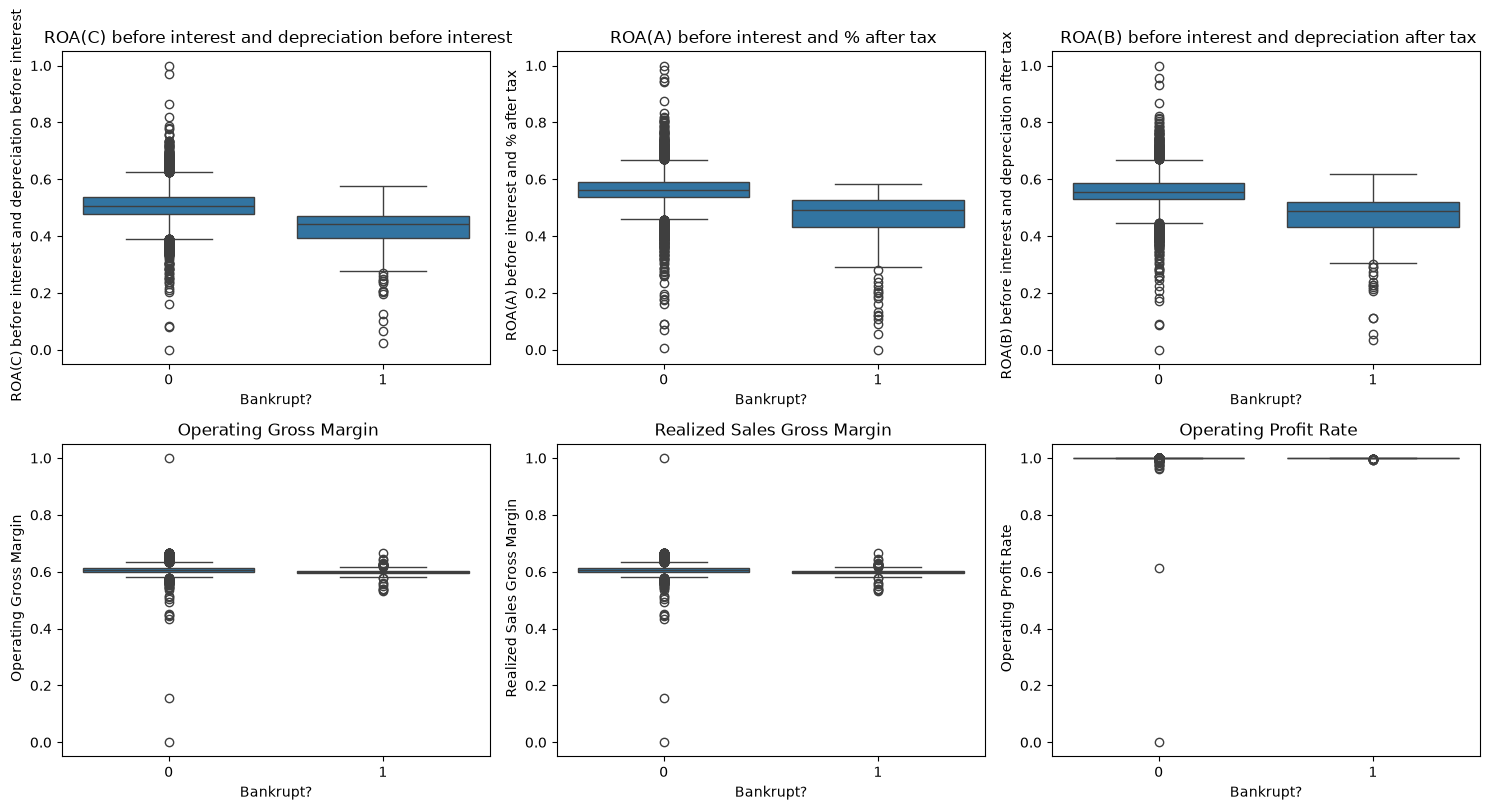

In [6]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas antar kelas.
fitur = [col for col in df.columns if col != target_col]

fitur_sample = fitur[:6]  # ambil beberapa fitur dulu biar nggak kebanyakan subplot

fig, axes = plt.subplots(2, 3, figsize=(15,8))
axes = axes.flatten()

for i, col in enumerate(fitur_sample):
    sns.boxplot(x=target_col, y=col, data=df, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

#### Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

In [7]:
# EDA tambahan: cek data duplikat
print('jumlah baris duplikat:', df.duplicated().sum())

jumlah baris duplikat: 0


### 2. Preprocessing

In [8]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
print('total missing value:', df.isnull().sum().sum())

total missing value: 0


In [9]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
# Catatan: Decision Tree secara konsep bisa menangani fitur kategorikal secara langsung tanpa One-Hot Encoding,
# tetapi implementasi DecisionTreeClassifier pada scikit-learn tetap mengharuskan input berupa angka.
print(df[fitur].dtypes.value_counts())
# semua fitur udah numerik, jadi nggak perlu encoding
df_encoded = df.copy()

float64    93
int64       2
Name: count, dtype: int64


In [10]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df_encoded[fitur]
y = df_encoded[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(X_train.shape, X_test.shape)

(5455, 95) (1364, 95)


**Catatan penting:** Decision Tree tidak memerlukan feature scaling (StandardScaler/MinMaxScaler). Split pada Decision Tree dilakukan berdasarkan threshold per fitur satu per satu, bukan berdasarkan jarak antar titik seperti pada KNN atau SVM. Jadi kalian tidak perlu melakukan scaling pada tahap ini.

### 3. Eksperimen Model

#### 3.1 Decision Tree dengan Kriteria Gini

Gini Impurity adalah kriteria default pada DecisionTreeClassifier di scikit-learn. Kriteria ini mengukur peluang kesalahan klasifikasi jika sebuah sampel dipilih secara acak dari suatu node.

In [11]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='gini' menggunakan train set.
model_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
model_gini.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [12]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_gini = model_gini.predict(X_test)

#### 3.2 Decision Tree dengan Kriteria Entropy

Entropy (Information Gain) adalah kriteria alternatif yang mengukur tingkat ketidakpastian distribusi kelas pada suatu node.

In [13]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='entropy' menggunakan train set.
# Gunakan nilai hyperparameter lain yang sama seperti model Gini di atas, agar perbandingan adil.
model_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
model_entropy.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

In [14]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_entropy = model_entropy.predict(X_test)

#### 3.3 Eksperimen Regularisasi: Pengaruh max_depth terhadap Overfitting

Decision Tree yang dibiarkan tumbuh tanpa batas cenderung overfitting terhadap data training. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai max_depth memengaruhi akurasi training dan testing.

In [15]:
# Latih beberapa model DecisionTreeClassifier dengan variasi nilai max_depth,
# misalnya 1, 2, 3, 5, 10, dan None (tanpa batas kedalaman).
# Gunakan kriteria split terbaik dari salah satu percobaan sebelumnya (Gini atau Entropy).
depths = [1, 2, 3, 5, 10, None]
models_depth = []

for d in depths:
    model = DecisionTreeClassifier(criterion='gini', max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    models_depth.append(model)

In [16]:
# Hitung akurasi pada train set dan test set untuk setiap nilai max_depth yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
train_acc = []
test_acc = []

for model in models_depth:
    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test)))

hasil_depth = pd.DataFrame({
    'max_depth': [str(d) for d in depths],
    'train_acc': train_acc,
    'test_acc': test_acc
})

hasil_depth

,max_depth,train_acc,test_acc
0,1,0.967736,0.967742
1,2,0.969936,0.969941
2,3,0.972319,0.969941
3,5,0.977452,0.968475
4,10,0.994684,0.960411
5,None,1.000000,0.961144


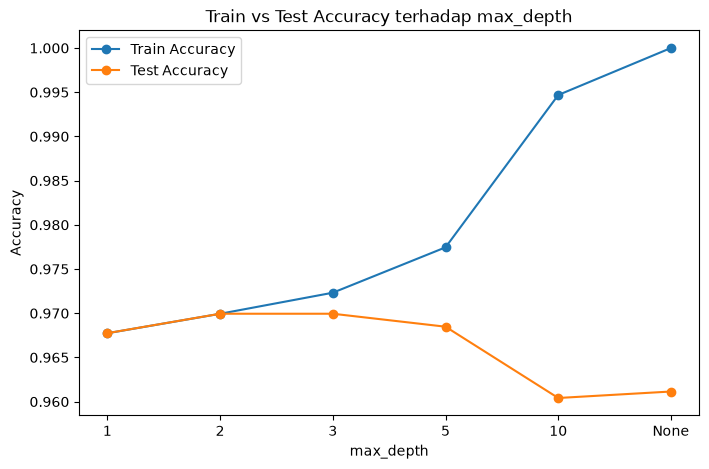

In [17]:
# Plot grafik akurasi training vs testing terhadap max_depth dalam satu chart.
# Amati pada titik berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).
plt.figure(figsize=(8,5))
plt.plot(hasil_depth['max_depth'], hasil_depth['train_acc'], marker='o', label='Train Accuracy')
plt.plot(hasil_depth['max_depth'], hasil_depth['test_acc'], marker='o', label='Test Accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy terhadap max_depth')
plt.legend()
plt.show()

### 4. Evaluasi Model

In [18]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model Gini dan Entropy.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
hasil = pd.DataFrame({
    'Model': ['Gini', 'Entropy'],
    'Accuracy': [accuracy_score(y_test, y_pred_gini), accuracy_score(y_test, y_pred_entropy)],
    'Precision': [precision_score(y_test, y_pred_gini), precision_score(y_test, y_pred_entropy)],
    'Recall': [recall_score(y_test, y_pred_gini), recall_score(y_test, y_pred_entropy)],
    'F1-Score': [f1_score(y_test, y_pred_gini), f1_score(y_test, y_pred_entropy)]
})

hasil

,Model,Accuracy,Precision,Recall,F1-Score
0,Gini,0.961144,0.400000,0.409091,0.404494
1,Entropy,0.964076,0.435897,0.386364,0.409639


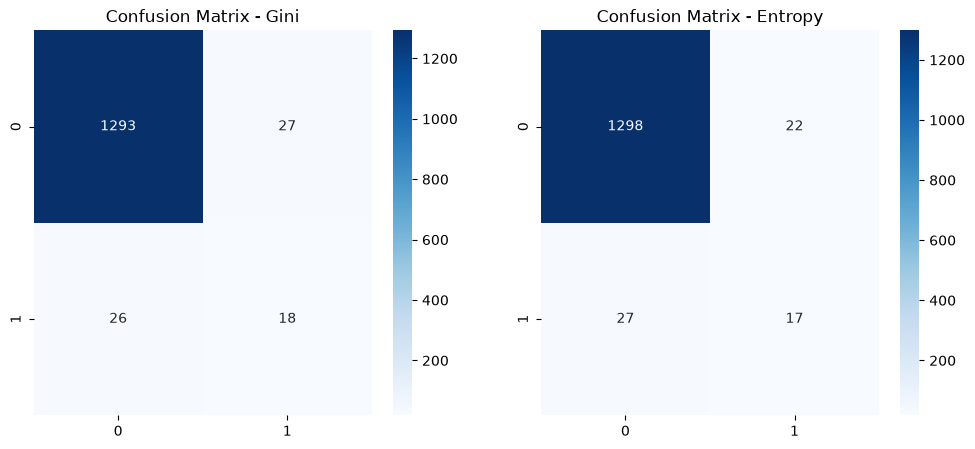

In [19]:
# Tampilkan Confusion Matrix untuk model Gini dan Entropy dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.
cm_gini = confusion_matrix(y_test, y_pred_gini)
cm_entropy = confusion_matrix(y_test, y_pred_entropy)

fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.heatmap(cm_gini, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix - Gini')

sns.heatmap(cm_entropy, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Confusion Matrix - Entropy')

plt.show()

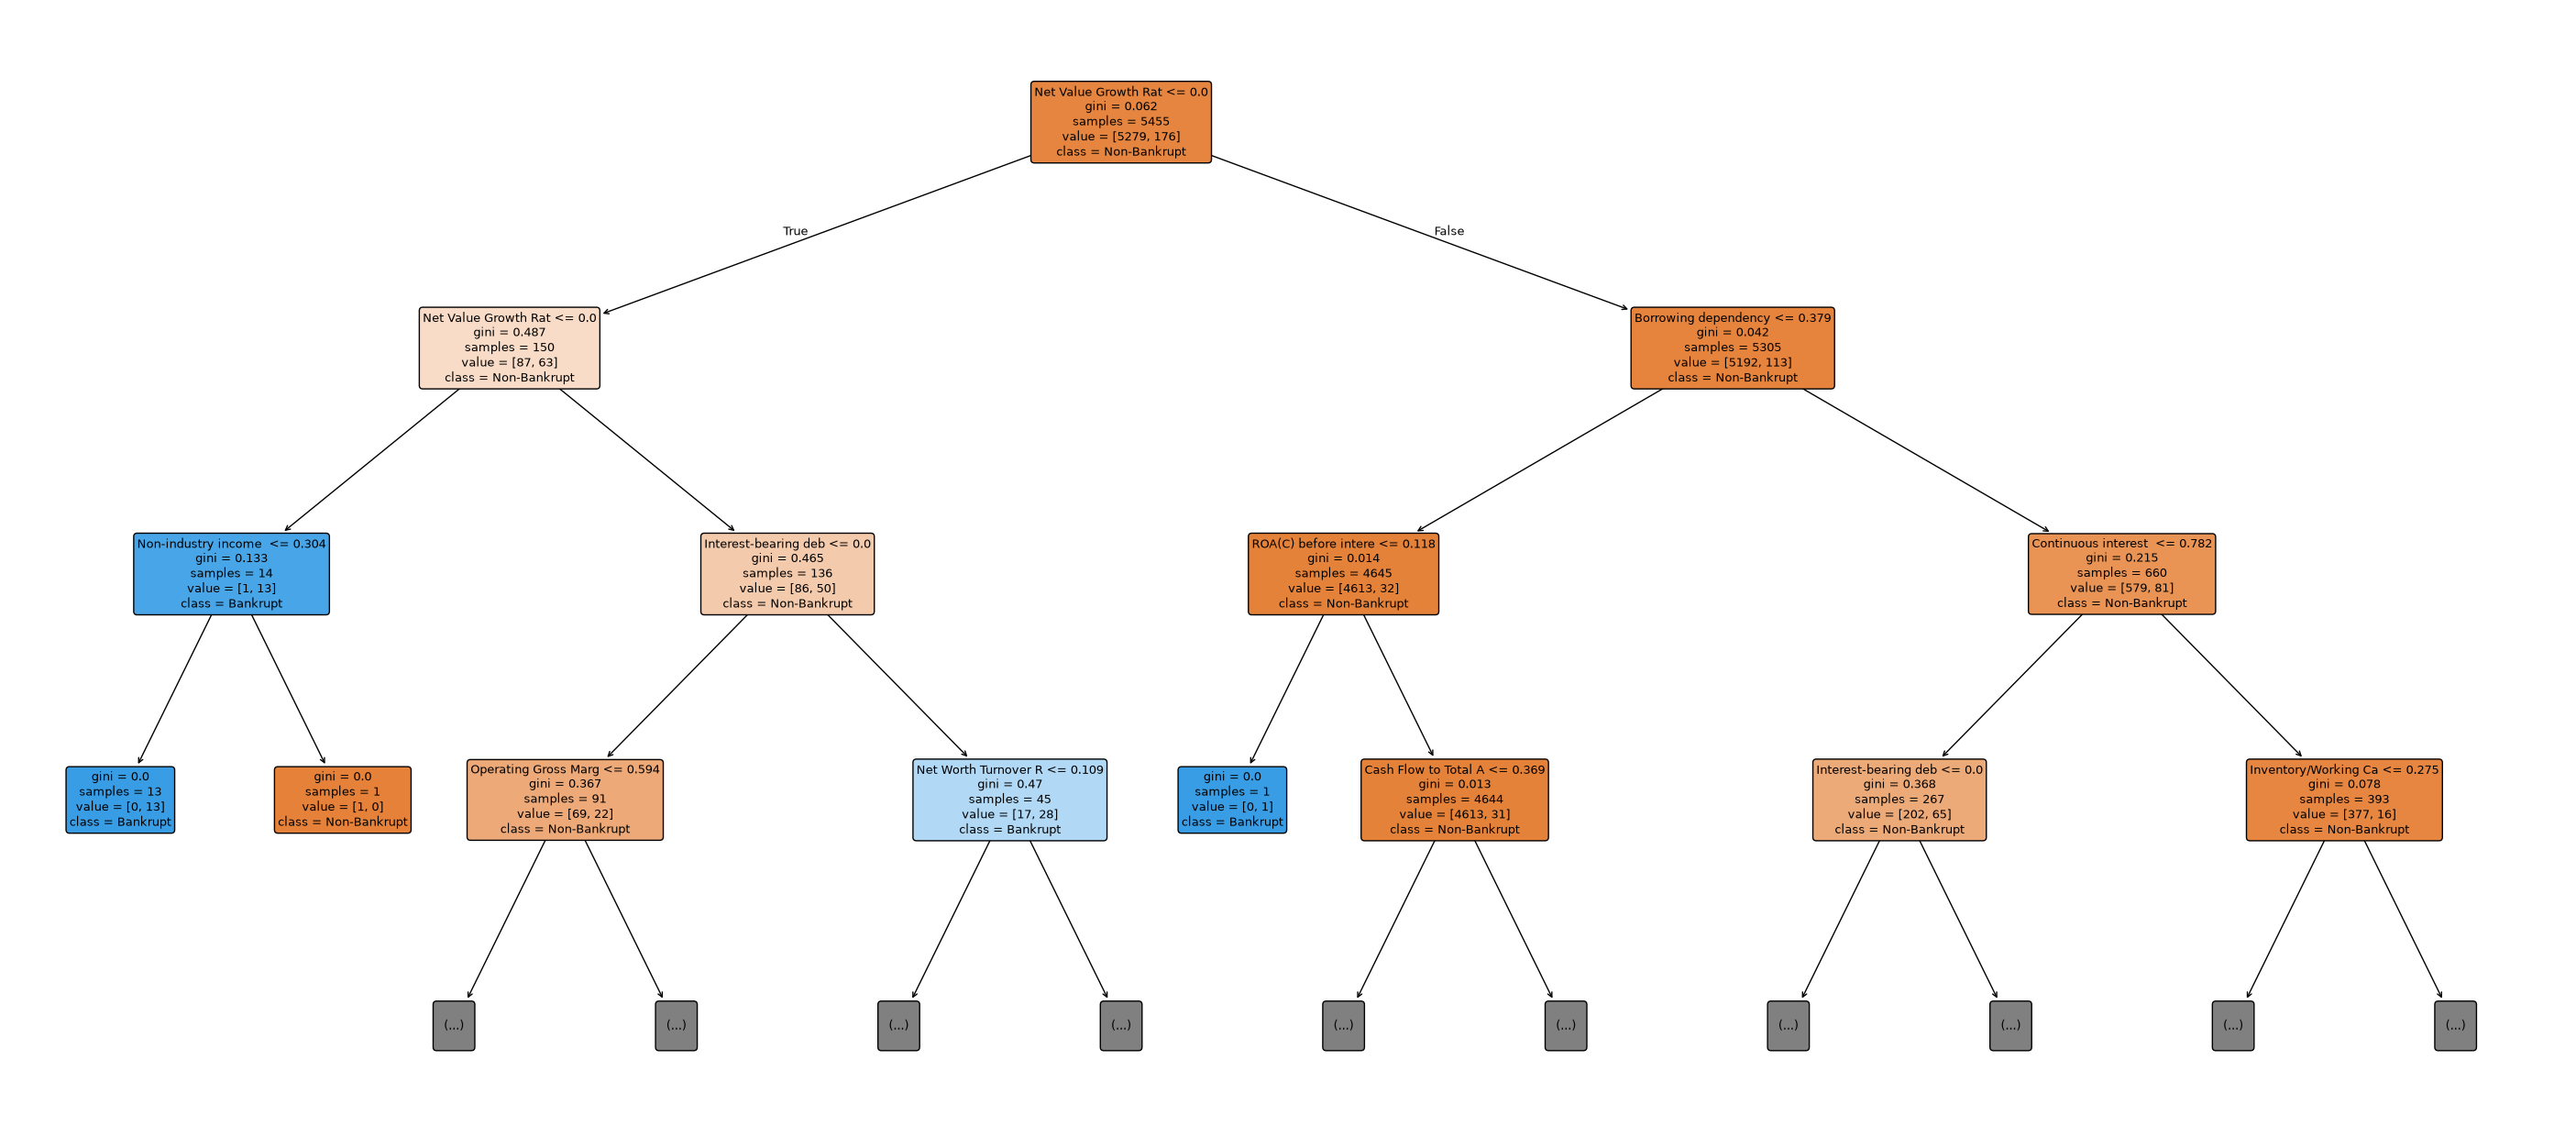

In [21]:
model_terbaik = model_gini  # ganti ke model_entropy kalau entropy lebih bagus dari tabel di atas

fitur_rapi = [f.strip()[:20] for f in fitur]

plt.figure(figsize=(36,16))
plot_tree(model_terbaik, max_depth=3, feature_names=fitur_rapi, class_names=['Non-Bankrupt', 'Bankrupt'],
          filled=True, fontsize=9, rounded=True)
plt.show()

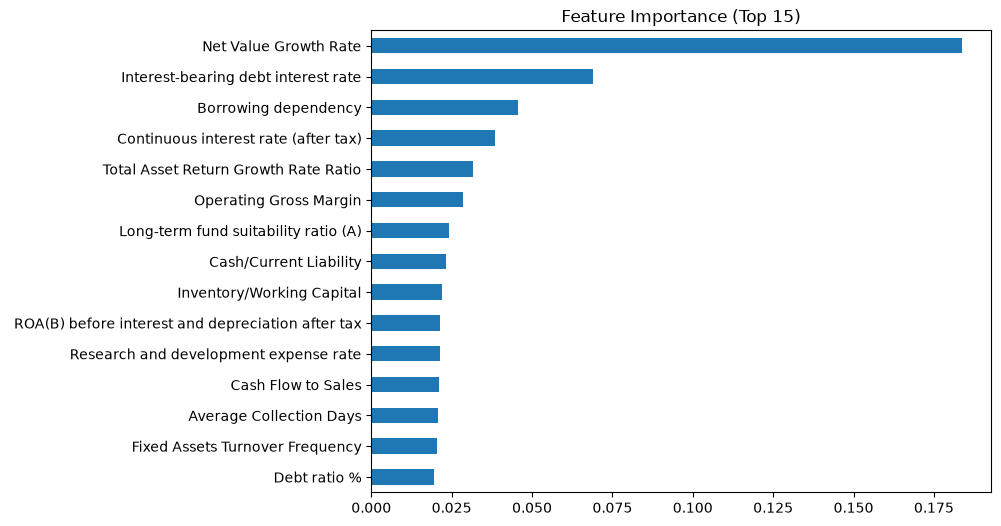

In [22]:
# Tampilkan feature importance dari model terbaik dalam bentuk bar chart horizontal.
# Urutkan dari fitur yang paling berpengaruh.
importance = pd.Series(model_terbaik.feature_importances_, index=fitur).sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
importance.sort_values().plot(kind='barh')
plt.title('Feature Importance (Top 15)')
plt.show()

# 5. Analisis

 #### Perbandingan Gini vs Entropy

Dari tabel evaluasi, akurasi Gini 0.961 dan Entropy 0.964, selisihnya tipis banget cuma 0.003. Precision Entropy (0.436) lebih tinggi dari Gini (0.400), tapi recall-nya malah lebih rendah (0.386 vs 0.409). Kalau dilihat dari confusion matrix, Entropy lebih jarang salah nebak kelas 0 jadi 1 (FP 22 vs 27), tapi lebih sering kelewat nangkep kelas 1 yang bener (FN 27 vs 26).

Perbedaan ini nggak signifikan soalnya kedua kriteria (Gini dan Entropy) pada dasarnya ngukur hal yang mirip, sama-sama nyari split yang bikin node paling "murni". Bedanya cuma di rumus matematisnya doang, jadi wajar kalau hasilnya nggak jauh beda.

#### Eksperimen max_depth

Dari grafik train vs test accuracy, mulai kelihatan overfitting di sekitar max_depth=5 ke atas. Di depth 1-3, train dan test accuracy masih deket-deketan (bahkan di depth 2 dan 3 test accuracy-nya 0.9699, hampir sama atau lebih tinggi dikit dari train). Tapi begitu masuk depth 5, train naik ke 0.977 sedangkan test malah mulai turun ke 0.968. Puncaknya di depth None, train accuracy sampe 1.000 (alias modelnya hafal semua data training), tapi test accuracy malah paling rendah di antara semua percobaan, cuma 0.961.

Ini ciri khas overfitting, model makin dalam makin "menghafal" data training termasuk noise-nya, tapi jadi kurang bisa generalisasi ke data baru. Titik paling optimal justru di depth kecil (2 atau 3), soalnya test accuracy-nya udah maksimal di situ dan gap sama train accuracy juga paling kecil.

#### Feature Importance

Fitur yang paling berpengaruh adalah Net Value Growth Rate, jauh di atas fitur lain (importance-nya sekitar 0.18, hampir 3x lipat fitur kedua). Disusul sama Interest-bearing debt interest rate, Borrowing dependency, dan Continuous interest rate (after tax). Semua fitur top ini kebanyakan berhubungan sama utang dan pertumbuhan nilai perusahaan, masuk akal soalnya perusahaan yang beban utangnya tinggi dan nilai asetnya nggak tumbuh emang cenderung lebih rawan bangkrut.

# 6. Kesimpulan dan Saran

Dari eksperimen ini, kriteria split Gini dan Entropy sama-sama menghasilkan performa yang mirip, jadi pemilihan kriteria nggak terlalu berpengaruh besar ke hasil akhir model. Yang lebih krusial justru pengaturan max_depth, karena model tanpa batas kedalaman jelas overfitting (train accuracy 1.000 tapi test accuracy paling rendah), sedangkan model dengan depth kecil (2-3) justru lebih stabil dan generalisasinya lebih bagus.

Perlu dicatat juga precision dan recall untuk kelas 1 (bankrupt) masih rendah banget, di bawah 0.45, padahal accuracy keseluruhan udah di atas 0.96. Ini karena datasetnya sangat imbalanced (cuma sekitar 3% data yang bankrupt), jadi model cenderung gampang nebak "tidak bangkrut" dan accuracy jadi keliatan tinggi padahal sebenernya model masih kesulitan ngenalin kasus bangkrut yang sesungguhnya.

Saran untuk eksperimen selanjutnya:
- Coba pruning pakai ccp_alpha buat liat apa bisa nyari titik optimal yang lebih presisi dibanding cuma ngatur max_depth manual
- Tangani masalah imbalanced data, misalnya pakai class_weight='balanced' atau teknik oversampling kayak SMOTE, biar model lebih peka ke kelas minoritas
- Bandingkan juga dengan model lain kayak Random Forest, yang biasanya lebih tahan overfitting dibanding single Decision Tree